# 🏎️ F1 2026 Australian Grand Prix — EDA, Data Cleaning & Merge
## Notebook 01

**Pipeline:**
1. Setup & Config
2. Load Raw Data
3. Data Cleaning
4. Merge → Master Tables
5. Free Practice Analysis
6. Qualifying Analysis
7. Race Analysis
8. Tyre Strategy
9. Weather Analysis
10. Correlation & Feature Insights
11. Save Processed Data


## 1. 📦 Setup & Config

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, ast, warnings
warnings.filterwarnings('ignore')

# ── Output folder cho hình ────────────────────────────────────
FIG_DIR = './figures_eda'
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    path = f'{FIG_DIR}/{name}'
    plt.savefig(path, dpi=130, bbox_inches='tight', facecolor='#0f0f0f')
    print(f'  💾 {path}')

# ── Style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f', 'axes.facecolor':   '#1a1a1a',
    'axes.edgecolor':   '#2e2e2e', 'axes.labelcolor':  '#cccccc',
    'xtick.color':      '#888888', 'ytick.color':      '#888888',
    'text.color':       '#dddddd', 'grid.color':       '#2a2a2a',
    'grid.linestyle':   '--',      'font.family':      'monospace',
    'axes.titlesize':   12,        'axes.labelsize':   10,
    'figure.dpi':       120,
})

TYRE_COLORS = {
    'SOFT':'#E8002D', 'MEDIUM':'#FFF200',
    'HARD':'#FFFFFF', 'INTER':'#39B54A', 'WET':'#0067FF',
}
TEAM_COLORS = {
    'Mercedes':'#00D7B6',     'Ferrari':'#E8002D',
    'McLaren':'#FF8000',      'Red Bull Racing':'#3671C6',
    'Aston Martin':'#229971', 'Alpine':'#FF87BC',
    'Williams':'#64C4FF',     'Haas F1 Team':'#B6BABD',
    'Audi':'#52E252',         'Racing Bulls':'#6692FF',
    'Cadillac':'#C8AA6E',
}
EXCLUDE = ['SAI', 'STR']

print(f'✅ Setup done')
print(f'   Figures → {FIG_DIR}/')


✅ Setup done
   Figures → ./figures_eda/


## 2. 📂 Load Raw Data

In [20]:
# ── Đổi đường dẫn nếu cần ────────────────────────────────────
DATA_DIR = '../AustralianGrandPrix'

fp1        = pd.read_csv(f'{DATA_DIR}/fp1_practice_1_fastest.csv',  index_col=0)
fp2        = pd.read_csv(f'{DATA_DIR}/fp2_practice_2_fastest.csv',  index_col=0)
fp3        = pd.read_csv(f'{DATA_DIR}/fp3_practice_3_fastest.csv',  index_col=0)
fp1_laps   = pd.read_csv(f'{DATA_DIR}/fp1_practice_1_laps.csv')
fp2_laps   = pd.read_csv(f'{DATA_DIR}/fp2_practice_2_laps.csv')
fp3_laps   = pd.read_csv(f'{DATA_DIR}/fp3_practice_3_laps.csv')
fp1_w      = pd.read_csv(f'{DATA_DIR}/fp1_practice_1_weather.csv')
fp2_w      = pd.read_csv(f'{DATA_DIR}/fp2_practice_2_weather.csv')
fp3_w      = pd.read_csv(f'{DATA_DIR}/fp3_practice_3_weather.csv')
quali      = pd.read_csv(f'{DATA_DIR}/q_qualifying_fastest.csv',    index_col=0)
quali_res  = pd.read_csv(f'{DATA_DIR}/q_qualifying_results.csv')
quali_w    = pd.read_csv(f'{DATA_DIR}/q_qualifying_weather.csv')
race       = pd.read_csv(f'{DATA_DIR}/r_race_results.csv')
race_laps  = pd.read_csv(f'{DATA_DIR}/r_race_laps.csv')
race_fast  = pd.read_csv(f'{DATA_DIR}/r_race_fastest_laps.csv')
race_pit   = pd.read_csv(f'{DATA_DIR}/r_race_pitstops.csv')
race_w     = pd.read_csv(f'{DATA_DIR}/r_race_weather.csv')

print('✅ Raw data loaded')
print(f'   FP1/FP2/FP3 fastest: {len(fp1)}/{len(fp2)}/{len(fp3)} drivers')
print(f'   FP1/FP2/FP3 laps:    {len(fp1_laps)}/{len(fp2_laps)}/{len(fp3_laps)} rows')
print(f'   Race results: {len(race)} | Race laps: {len(race_laps)} | Pit stops: {len(race_pit)}')


✅ Raw data loaded
   FP1/FP2/FP3 fastest: 21/22/20 drivers
   FP1/FP2/FP3 laps:    487/544/377 rows
   Race results: 22 | Race laps: 1007 | Pit stops: 19


## 3. 🧹 Data Cleaning

| # | Vấn đề | Xử lý |
|---|--------|-------|
| 1 | SAI & STR thiếu FP3/Quali | Drop khỏi fastest tables |
| 2 | VER qualifying = 102s (lap abort) | Đánh dấu `quali_anomaly=True` |
| 3 | `IsPersonalBest` có NaN, dtype object | `fillna(False)` → bool |
| 4 | Q1/Q2/Q3 dạng timedelta string | Parse → giây (float) |
| 5 | `GridPosition` NaN trong quali_res | Lấy từ race results |
| 6 | `fp_improvement` NaN (ALO thiếu FP1) | fillna median |


In [21]:
# ── 3.1 Fastest tables ────────────────────────────────────────
for df in [fp1, fp2, fp3, quali]:
    df.drop(df[df['Driver'].isin(EXCLUDE)].index, inplace=True)
    df.reset_index(drop=True, inplace=True)

# Chuẩn hóa tên cột Gap
for df in [fp1, fp2, fp3]:
    if 'Gap_to_P1_s' in df.columns:
        df.rename(columns={'Gap_to_P1_s': 'Gap_s'}, inplace=True)
if 'Gap_to_Pole_s' in quali.columns:
    quali.rename(columns={'Gap_to_Pole_s': 'Gap_s'}, inplace=True)

# Đánh dấu VER anomaly
quali['quali_anomaly'] = quali['Driver'] == 'VER'

print(f'✅ Fastest tables: {len(fp3)} drivers sau khi drop {EXCLUDE}')

# ── 3.2 Race results clean ────────────────────────────────────
race_clean = race[['Abbreviation','FullName','TeamName','Position',
                   'ClassifiedPosition','GridPosition','Status','Points','Laps']].copy()
race_clean.columns = ['Driver','FullName','Team','Position',
                      'ClassifiedPosition','GridPosition','Status','Points','Laps']
race_clean['Position']     = pd.to_numeric(race_clean['Position'],     errors='coerce')
race_clean['GridPosition'] = pd.to_numeric(race_clean['GridPosition'], errors='coerce')
race_clean['Points']       = pd.to_numeric(race_clean['Points'],       errors='coerce')
race_clean['dnf']          = race_clean['Status'].isin(['Retired','Did not start'])
race_clean['finished']     = race_clean['Status'] == 'Finished'
race_clean['positions_gained'] = race_clean['GridPosition'] - race_clean['Position']

# GridPosition map (dùng cho ML sau này)
GRID_MAP = dict(zip(race_clean['Driver'], race_clean['GridPosition']))

# ── 3.3 FP & race laps ────────────────────────────────────────
race_laps['IsPersonalBest'] = race_laps['IsPersonalBest'].fillna(False).astype(bool)
race_laps['FreshTyre']      = race_laps['FreshTyre'].astype(bool)

# ── 3.4 Qualifying results: parse Q1/Q2/Q3 timedelta ─────────
def parse_td(val):
    try:
        return pd.to_timedelta(val).total_seconds()
    except:
        return np.nan

for col in ['Q1','Q2','Q3']:
    quali_res[f'{col}_s'] = quali_res[col].apply(parse_td)

quali_res = quali_res.rename(columns={'Abbreviation':'Driver'})
# GridPosition từ race_clean (quali_res GridPosition toàn NaN)
quali_res['GridPosition'] = quali_res['Driver'].map(GRID_MAP)
quali_res['eliminated_Q1'] = quali_res['Q2_s'].isna()
quali_res['eliminated_Q2'] = (~quali_res['Q2_s'].isna()) & quali_res['Q3_s'].isna()
quali_res['reached_Q3']    = quali_res['Q3_s'].notna()

# ── 3.5 Pit stops ─────────────────────────────────────────────
def parse_pit(val):
    try: return [int(x) for x in ast.literal_eval(val)]
    except: return []

race_pit.columns  = ['Driver','pit_stops','pit_laps_raw']
race_pit['pit_laps']  = race_pit['pit_laps_raw'].apply(parse_pit)
race_pit['first_pit'] = race_pit['pit_laps'].apply(lambda x: min(x) if x else np.nan)
race_pit['last_pit']  = race_pit['pit_laps'].apply(lambda x: max(x) if x else np.nan)

# ── 3.6 Weather: parse Time ───────────────────────────────────
for df, name in [(fp1_w,'fp1'),(fp2_w,'fp2'),(fp3_w,'fp3'),(quali_w,'q'),(race_w,'r')]:
    df['Time_s'] = pd.to_timedelta(df['Time'], errors='coerce').dt.total_seconds()
    df['Rainfall'] = df['Rainfall'].astype(bool)

# Helper maps
driver_team  = dict(zip(race_clean['Driver'], race_clean['Team']))
driver_color = {d: TEAM_COLORS.get(t,'#888888') for d,t in driver_team.items()}

print('✅ Cleaning done')
print(f'   GRID_MAP: {GRID_MAP}')


✅ Fastest tables: 20 drivers sau khi drop ['SAI', 'STR']
✅ Cleaning done
   GRID_MAP: {'RUS': 1.0, 'ANT': 2.0, 'LEC': 4.0, 'HAM': 7.0, 'NOR': 6.0, 'VER': 20.0, 'BEA': 12.0, 'LIN': 9.0, 'BOR': 10.0, 'GAS': 14.0, 'OCO': 13.0, 'ALB': 15.0, 'LAW': 8.0, 'COL': 16.0, 'SAI': 21.0, 'PER': 18.0, 'STR': 22.0, 'ALO': 17.0, 'BOT': 19.0, 'HAD': 3.0, 'PIA': 5.0, 'HUL': 11.0}


## 4. 🔗 Merge → Master Tables

In [22]:
# ── df_drivers: 1 row per driver ─────────────────────────────
fp1_m = fp1[['Driver','DriverNumber','LapTime_s','Sector1Time_s',
             'Sector2Time_s','Sector3Time_s','SpeedFL','Gap_s']].copy()
fp1_m.columns = ['Driver','DriverNumber','fp1_laptime',
                 'fp1_s1','fp1_s2','fp1_s3','fp1_speed','fp1_gap']

fp2_m = fp2[['Driver','LapTime_s','Sector1Time_s',
             'Sector2Time_s','Sector3Time_s','SpeedFL','Gap_s']].copy()
fp2_m.columns = ['Driver','fp2_laptime','fp2_s1','fp2_s2','fp2_s3','fp2_speed','fp2_gap']

fp3_m = fp3[['Driver','LapTime_s','Sector1Time_s',
             'Sector2Time_s','Sector3Time_s','SpeedFL','Gap_s']].copy()
fp3_m.columns = ['Driver','fp3_laptime','fp3_s1','fp3_s2','fp3_s3','fp3_speed','fp3_gap']

q_m = quali[['Driver','LapTime_s','Sector1Time_s','Sector2Time_s',
             'Sector3Time_s','SpeedFL','Gap_s','quali_anomaly']].copy()
q_m.columns = ['Driver','quali_laptime','quali_s1','quali_s2','quali_s3',
               'quali_speed','quali_gap','quali_anomaly']

qr_m = quali_res[['Driver','Q1_s','Q2_s','Q3_s','GridPosition',
                  'eliminated_Q1','eliminated_Q2','reached_Q3']].copy()

race_m = race_clean[['Driver','Team','Position','ClassifiedPosition',
                     'Status','Points','dnf','finished','positions_gained']].copy()
race_m.columns = ['Driver','Team','race_pos','classified_pos',
                  'race_status','race_points','dnf','finished','positions_gained']

pit_m  = race_pit[['Driver','pit_stops','pit_laps','first_pit','last_pit']].copy()

fast_m = race_fast[['Driver','LapTime','SpeedFL','Compound']].copy()
fast_m.columns = ['Driver','race_fastest_lap_s','race_fastest_speed','race_fastest_compound']

df_drivers = (
    fp1_m
    .merge(fp2_m,  on='Driver', how='outer')
    .merge(fp3_m,  on='Driver', how='outer')
    .merge(q_m,    on='Driver', how='outer')
    .merge(qr_m,   on='Driver', how='left')
    .merge(race_m, on='Driver', how='left')
    .merge(pit_m,  on='Driver', how='left')
    .merge(fast_m, on='Driver', how='left')
)

# ── Fix GridPosition từ GRID_MAP (quali_res GridPosition có NaN) ──
df_drivers['GridPosition'] = df_drivers['Driver'].map(GRID_MAP)

# ── Engineered features ───────────────────────────────────────
df_drivers['fp_improvement']   = df_drivers['fp1_laptime'] - df_drivers['fp3_laptime']
df_drivers['fp2_to_fp3_delta'] = df_drivers['fp2_laptime'] - df_drivers['fp3_laptime']
df_drivers['quali_vs_fp3']     = df_drivers['quali_laptime'] - df_drivers['fp3_laptime']
df_drivers['fp3_sector_std']   = df_drivers[['fp3_s1','fp3_s2','fp3_s3']].std(axis=1)

# fillna cho ALO (không có FP1)
df_drivers['fp_improvement'] = df_drivers['fp_improvement'].fillna(
    df_drivers['fp_improvement'].median()
)
df_drivers['fp2_to_fp3_delta'] = df_drivers['fp2_to_fp3_delta'].fillna(
    df_drivers['fp2_to_fp3_delta'].median()
)

df_drivers['team_color'] = df_drivers['Team'].map(TEAM_COLORS).fillna('#888888')
df_drivers = df_drivers.sort_values('race_pos').reset_index(drop=True)

print(f'✅ df_drivers: {df_drivers.shape}')
print()

# Null check
null_check = df_drivers.isnull().sum()
null_check = null_check[null_check > 0]
if len(null_check):
    print('Null còn lại (expected):')
    for col, cnt in null_check.items():
        print(f'  {col:35s}: {cnt}')
else:
    print('Không có NaN trong các cột quan trọng ✅')


✅ df_drivers: (20, 54)

Null còn lại (expected):
  DriverNumber                       : 1
  fp1_laptime                        : 1
  fp1_s1                             : 1
  fp1_s2                             : 1
  fp1_s3                             : 1
  fp1_speed                          : 1
  fp1_gap                            : 1
  Q1_s                               : 1
  Q2_s                               : 4
  Q3_s                               : 11
  pit_stops                          : 3
  pit_laps                           : 3
  first_pit                          : 3
  last_pit                           : 3
  race_fastest_lap_s                 : 2
  race_fastest_speed                 : 2
  race_fastest_compound              : 2


In [23]:
# ── df_laps: gộp FP + Race laps ──────────────────────────────
COMMON = ['Driver','DriverNumber','Team','LapNumber','LapTime',
          'Sector1Time','Sector2Time','Sector3Time',
          'SpeedI1','SpeedI2','SpeedFL','SpeedST',
          'Compound','TyreLife','FreshTyre','IsPersonalBest','TrackStatus']

def tag(df, session):
    df = df.copy()
    df['session'] = session
    if 'LapTime_s' in df.columns:
        df = df.rename(columns={
            'LapTime_s':'LapTime','Sector1Time_s':'Sector1Time',
            'Sector2Time_s':'Sector2Time','Sector3Time_s':'Sector3Time'
        })
    keep = ['session'] + [c for c in COMMON if c in df.columns]
    return df[keep]

dfs = []
for src, sess in [(fp1_laps,'FP1'),(fp2_laps,'FP2'),(fp3_laps,'FP3'),(race_laps,'Race')]:
    src = src[~src['Driver'].isin(EXCLUDE)].copy()
    if 'IsPersonalBest' in src.columns:
        src['IsPersonalBest'] = src['IsPersonalBest'].fillna(False).astype(bool)
    dfs.append(tag(src, sess))

df_laps = pd.concat(dfs, ignore_index=True)
session_order = {'FP1':1,'FP2':2,'FP3':3,'Race':4}
df_laps['session_order'] = df_laps['session'].map(session_order)
df_laps = df_laps.sort_values(['session_order','Driver','LapNumber']).reset_index(drop=True)

print(f'✅ df_laps: {df_laps.shape}')
print(df_laps.groupby('session')['LapTime'].agg(['count','mean','min']).round(2))


✅ df_laps: (2259, 19)
         count    mean    min
session                      
FP1        368  102.28  80.27
FP2        439   99.14  79.73
FP3        283  101.25  79.05
Race       902   87.74  82.09


## 5. 📊 Free Practice Analysis

  💾 ./figures_eda/01_fp_pace_evolution.png


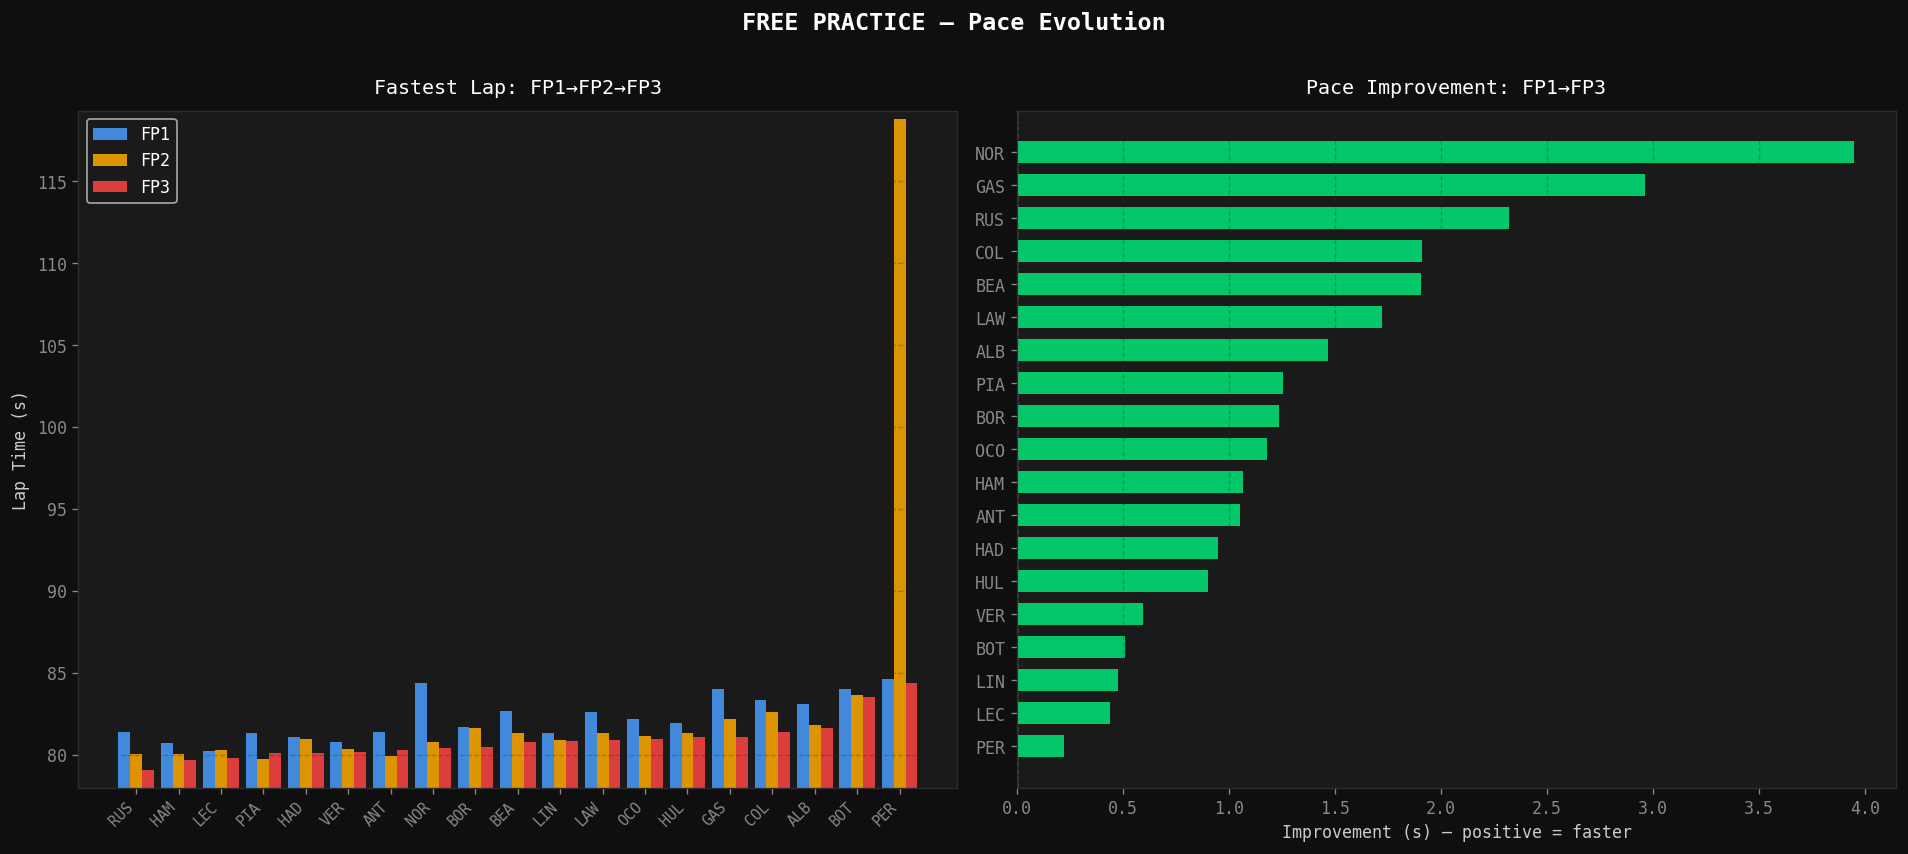

In [24]:
# ── 5.1 Pace evolution FP1 → FP2 → FP3 ─────────────────────
fp_cmp = (
    fp1[['Driver','LapTime_s']].rename(columns={'LapTime_s':'FP1'})
    .merge(fp2[['Driver','LapTime_s']].rename(columns={'LapTime_s':'FP2'}), on='Driver')
    .merge(fp3[['Driver','LapTime_s']].rename(columns={'LapTime_s':'FP3'}), on='Driver')
)
fp_cmp['Improvement'] = fp_cmp['FP1'] - fp_cmp['FP3']
fp_cmp = fp_cmp.sort_values('FP3')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0f0f0f')

ax = axes[0]
x, w = np.arange(len(fp_cmp)), 0.28
for i,(col,c) in enumerate(zip(['FP1','FP2','FP3'],['#4a9eff','#ffaa00','#ff4444'])):
    ax.bar(x+i*w, fp_cmp[col], width=w, color=c, alpha=0.85, label=col)
ax.set_xticks(x+w); ax.set_xticklabels(fp_cmp['Driver'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Lap Time (s)'); ax.set_title('Fastest Lap: FP1→FP2→FP3', color='white', pad=10)
ax.legend(facecolor='#1a1a1a', labelcolor='white')
ax.set_ylim(78, fp_cmp[['FP1','FP2','FP3']].max().max()+0.5); ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
imp = fp_cmp.sort_values('Improvement', ascending=True)
bar_c = ['#00e676' if v>=0 else '#ff1744' for v in imp['Improvement']]
ax2.barh(imp['Driver'], imp['Improvement'], color=bar_c, alpha=0.85, height=0.65)
ax2.axvline(0, color='white', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Improvement (s) — positive = faster')
ax2.set_title('Pace Improvement: FP1→FP3', color='white', pad=10)
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('FREE PRACTICE — Pace Evolution', color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); savefig('01_fp_pace_evolution.png'); plt.show()


  💾 ./figures_eda/02_fp3_sector_heatmap.png


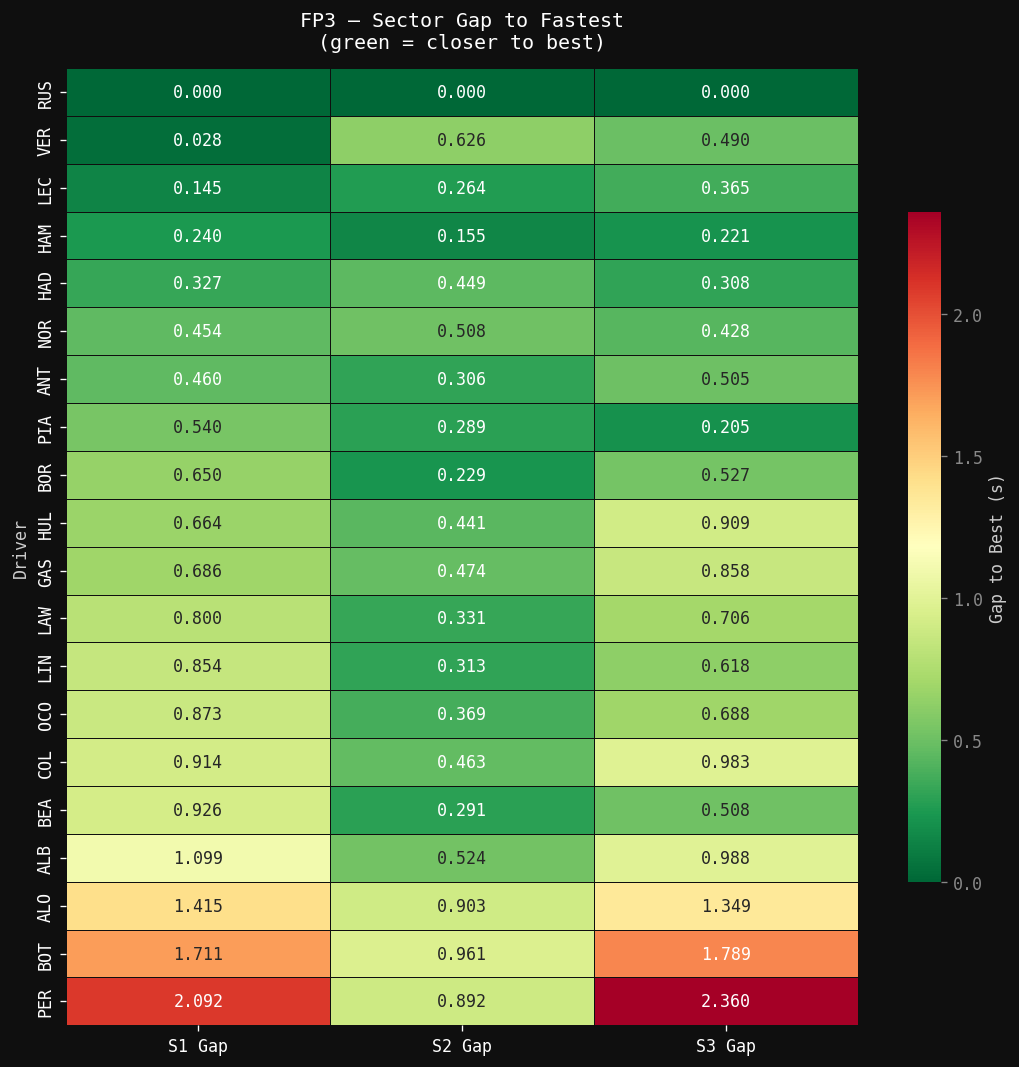

In [25]:
# ── 5.2 FP3 Sector Heatmap ───────────────────────────────────
sec = fp3[['Driver','Sector1Time_s','Sector2Time_s','Sector3Time_s']].set_index('Driver')
sec_gap = sec.copy()
for col in sec_gap.columns:
    sec_gap[col] = (sec_gap[col] - sec_gap[col].min()).round(3)
sec_gap.columns = ['S1 Gap','S2 Gap','S3 Gap']
sec_gap = sec_gap.sort_values('S1 Gap')

fig, ax = plt.subplots(figsize=(9, 9))
fig.patch.set_facecolor('#0f0f0f')
sns.heatmap(sec_gap, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.3f',
            linewidths=0.4, linecolor='#0f0f0f', cbar_kws={'label':'Gap to Best (s)','shrink':0.7})
ax.set_title('FP3 — Sector Gap to Fastest\n(green = closer to best)', color='white', pad=12)
ax.tick_params(colors='white')
plt.tight_layout(); savefig('02_fp3_sector_heatmap.png'); plt.show()


## 6. 🏁 Qualifying Analysis

  💾 ./figures_eda/03_qualifying_gap.png


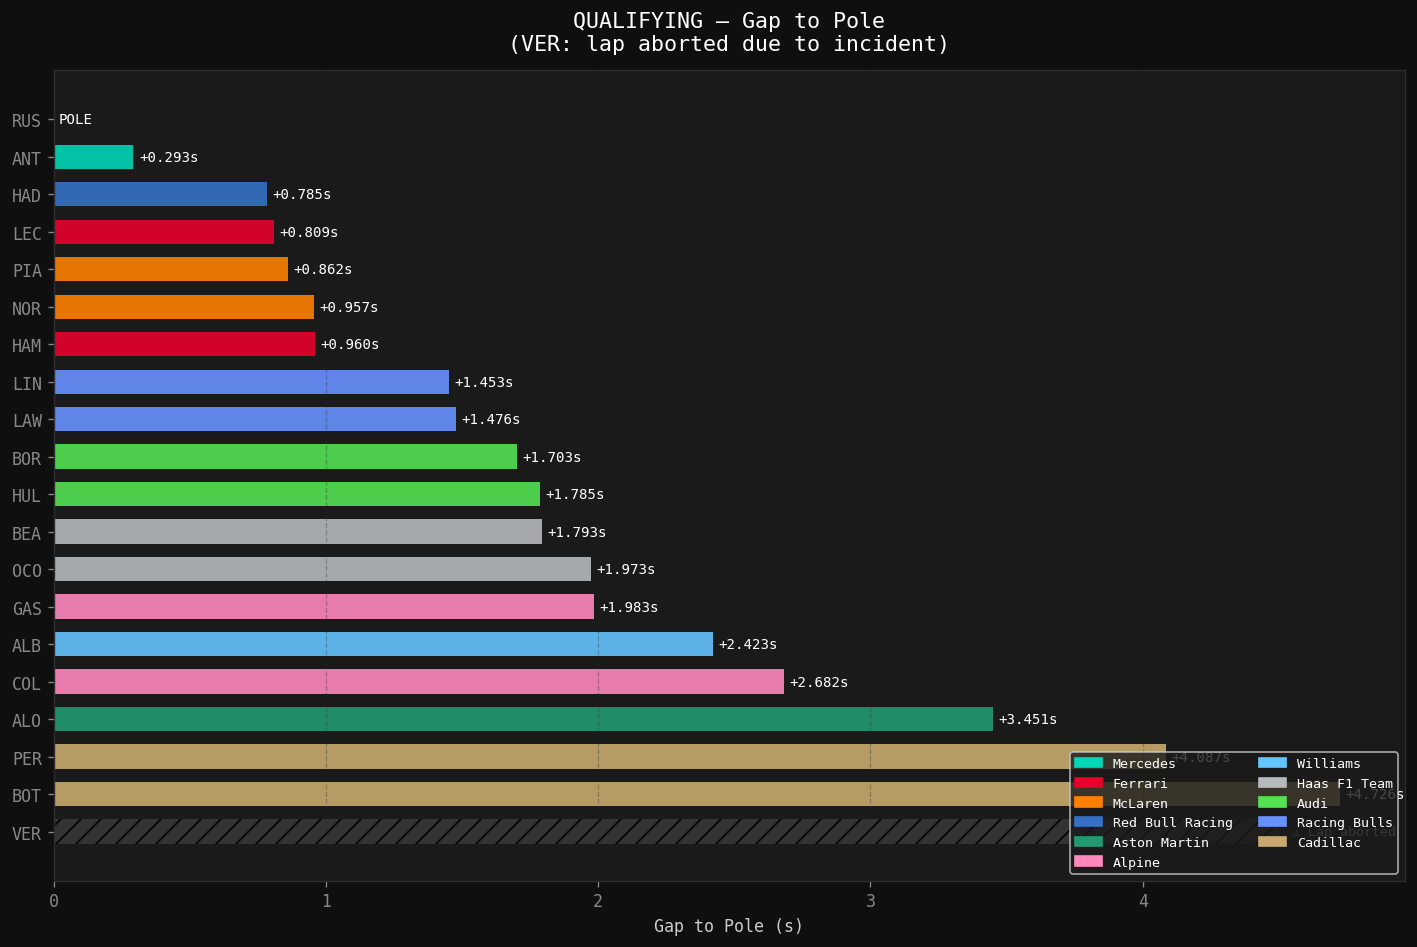

In [26]:
# ── 6.1 Gap to pole (exclude VER anomaly) ────────────────────
q_plot = quali[~quali['quali_anomaly']].sort_values('Gap_s').copy()
q_plot['color'] = q_plot['Driver'].map(lambda d: TEAM_COLORS.get(driver_team.get(d,''),'#888888'))

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0f0f0f')

for _, row in q_plot.iterrows():
    ax.barh(row['Driver'], row['Gap_s'], color=row['color'], alpha=0.9, height=0.65)
    label = f'+{row["Gap_s"]:.3f}s' if row['Gap_s']>0 else 'POLE'
    ax.text(row['Gap_s']+0.02, row['Driver'], label, va='center', fontsize=8.5, color='white')

# VER anomaly
ax.barh('VER', 4.5, color='#444', alpha=0.6, height=0.65, hatch='//')
ax.text(4.55, 'VER', '⚠ Lap aborted', va='center', fontsize=8, color='#aaaaaa')

ax.invert_yaxis()
ax.set_xlabel('Gap to Pole (s)')
ax.set_title('QUALIFYING — Gap to Pole\n(VER: lap aborted due to incident)',
             color='white', fontsize=13, pad=12)
ax.grid(axis='x', alpha=0.3)

legend_items = [mpatches.Patch(color=c, label=t)
                for t,c in TEAM_COLORS.items() if t in driver_team.values()]
ax.legend(handles=legend_items, loc='lower right',
          facecolor='#1a1a1a', labelcolor='white', fontsize=8, ncol=2)
plt.tight_layout(); savefig('03_qualifying_gap.png'); plt.show()


  💾 ./figures_eda/04_qualifying_segments.png


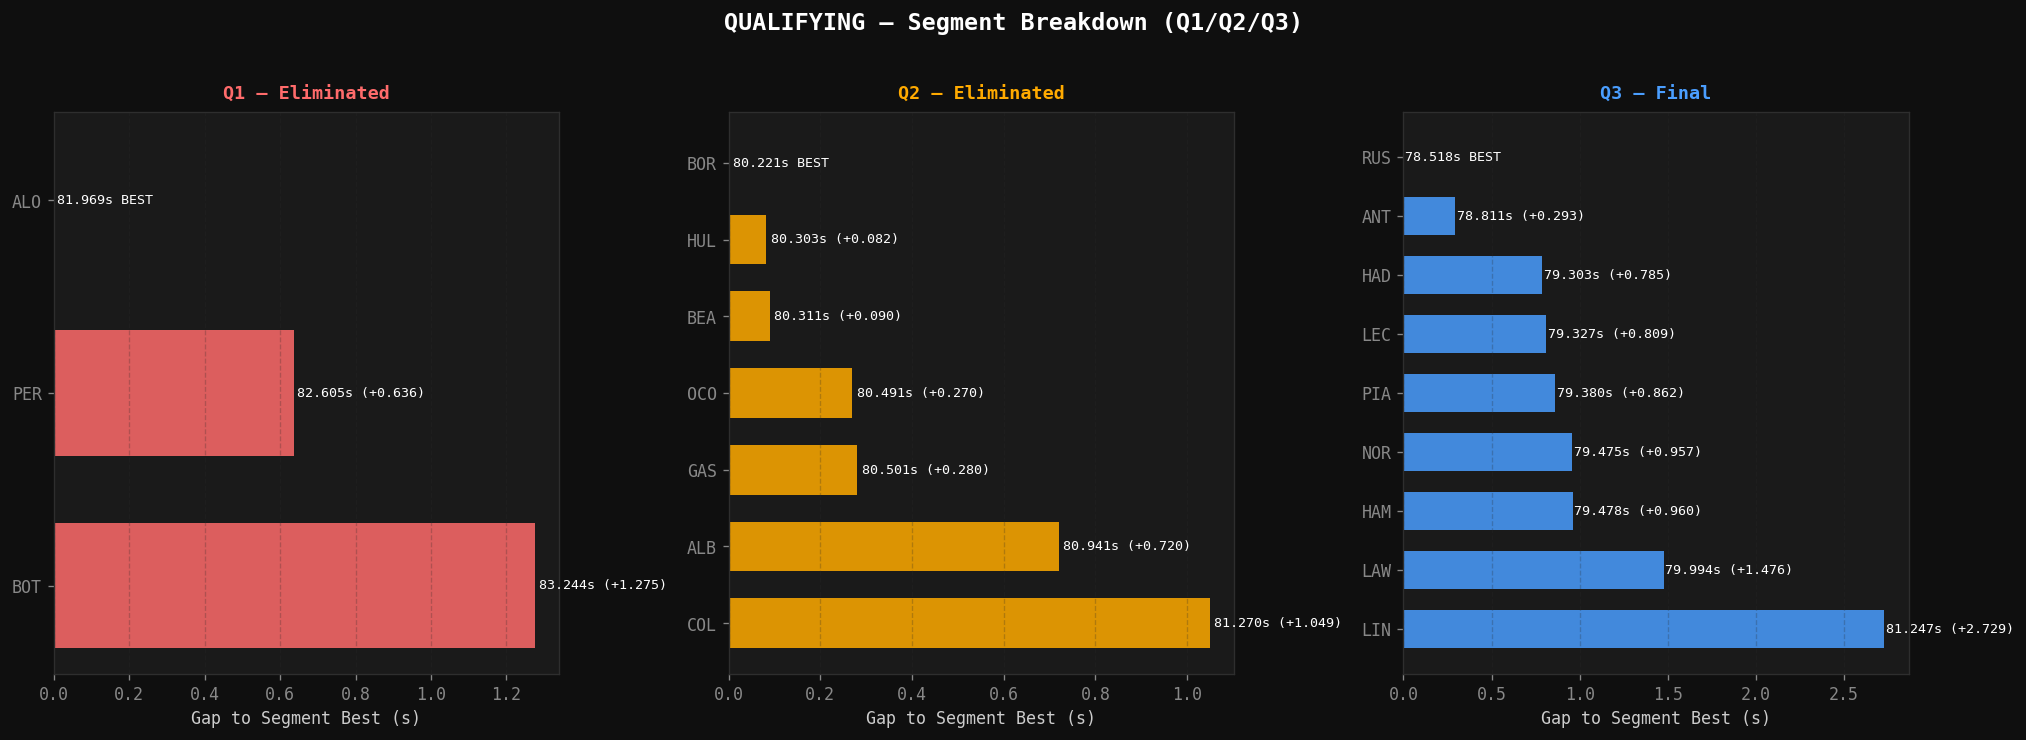

In [27]:
# ── 6.2 Q1/Q2/Q3 segment breakdown ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.patch.set_facecolor('#0f0f0f')

seg_info = [
    (quali_res[quali_res['eliminated_Q1']].dropna(subset=['Q1_s']).sort_values('Q1_s'), 'Q1_s', 'Q1 — Eliminated', '#ff6b6b'),
    (quali_res[quali_res['eliminated_Q2']].dropna(subset=['Q2_s']).sort_values('Q2_s'), 'Q2_s', 'Q2 — Eliminated', '#ffaa00'),
    (quali_res[quali_res['reached_Q3']].dropna(subset=['Q3_s']).sort_values('Q3_s'),    'Q3_s', 'Q3 — Final',      '#4a9eff'),
]

for ax, (data, col, title, color) in zip(axes, seg_info):
    best = data[col].min()
    ax.barh(data['Driver'], data[col]-best, color=color, alpha=0.85, height=0.65)
    for _, row in data.iterrows():
        gap = row[col]-best
        ax.text(gap+0.01, row['Driver'],
                f'{row[col]:.3f}s (+{gap:.3f})' if gap>0 else f'{row[col]:.3f}s BEST',
                va='center', fontsize=8, color='white')
    ax.invert_yaxis()
    ax.set_title(title, color=color, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Gap to Segment Best (s)')
    ax.grid(axis='x', alpha=0.25)

plt.suptitle('QUALIFYING — Segment Breakdown (Q1/Q2/Q3)',
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); savefig('04_qualifying_segments.png'); plt.show()


## 7. 🏆 Race Analysis

  💾 ./figures_eda/05_race_grid_vs_finish.png


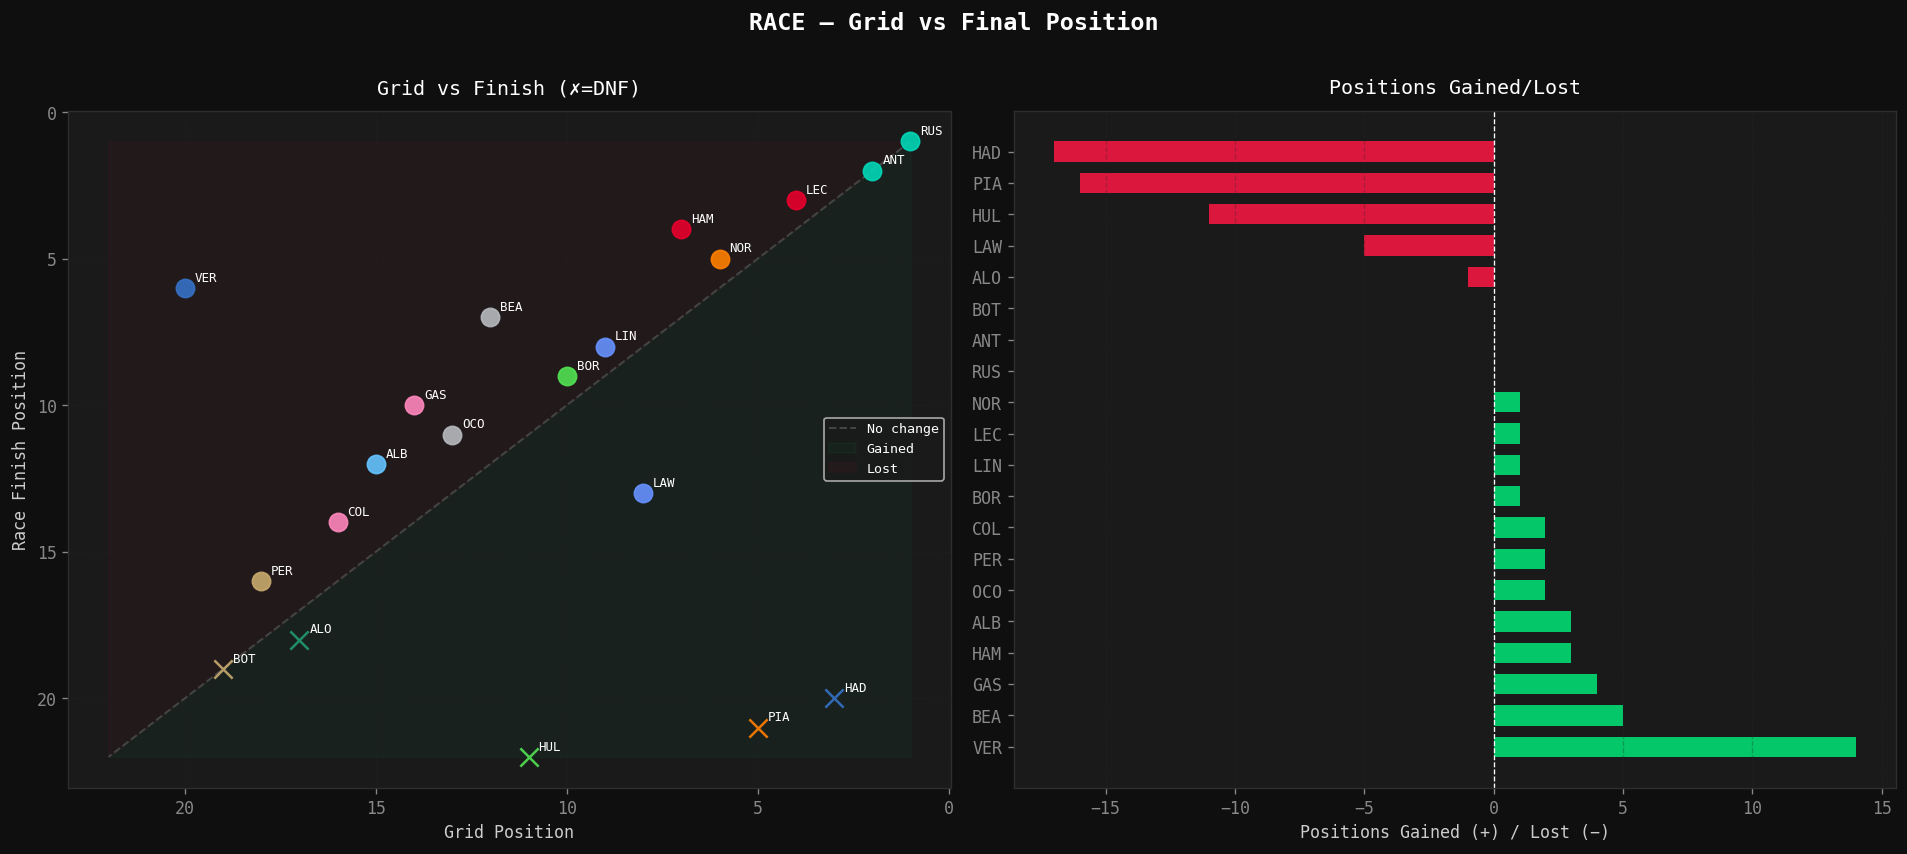

In [28]:
# ── 7.1 Grid vs Finish + Positions gained/lost ───────────────
r = race_clean[~race_clean['Driver'].isin(EXCLUDE)].dropna(subset=['Position','GridPosition'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0f0f0f')

ax = axes[0]
for _, row in r.iterrows():
    c = TEAM_COLORS.get(row['Team'], '#888888')
    m = 'x' if row['dnf'] else 'o'
    ax.scatter(row['GridPosition'], row['Position'], color=c, s=120, marker=m, zorder=5, alpha=0.9)
    ax.annotate(row['Driver'], (row['GridPosition'], row['Position']),
                textcoords='offset points', xytext=(6,4), fontsize=7.5, color='white')
ax.plot([1,22],[1,22],'--',color='#444',linewidth=1.2,label='No change')
ax.fill_between([1,22],[1,22],[22,22], alpha=0.04, color='#00e676', label='Gained')
ax.fill_between([1,22],[1,1],[1,22],   alpha=0.04, color='#ff1744', label='Lost')
ax.set_xlabel('Grid Position'); ax.set_ylabel('Race Finish Position')
ax.set_title('Grid vs Finish (✗=DNF)', color='white', pad=10)
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.invert_yaxis(); ax.invert_xaxis(); ax.grid(alpha=0.2)

ax2 = axes[1]
pg = r.sort_values('positions_gained', ascending=False)
bar_c = ['#00e676' if v>0 else '#ff1744' if v<0 else '#888' for v in pg['positions_gained']]
ax2.barh(pg['Driver'], pg['positions_gained'], color=bar_c, alpha=0.85, height=0.65)
ax2.axvline(0, color='white', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Positions Gained (+) / Lost (−)')
ax2.set_title('Positions Gained/Lost', color='white', pad=10)
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('RACE — Grid vs Final Position',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); savefig('05_race_grid_vs_finish.png'); plt.show()


  💾 ./figures_eda/06_race_pace_top5.png


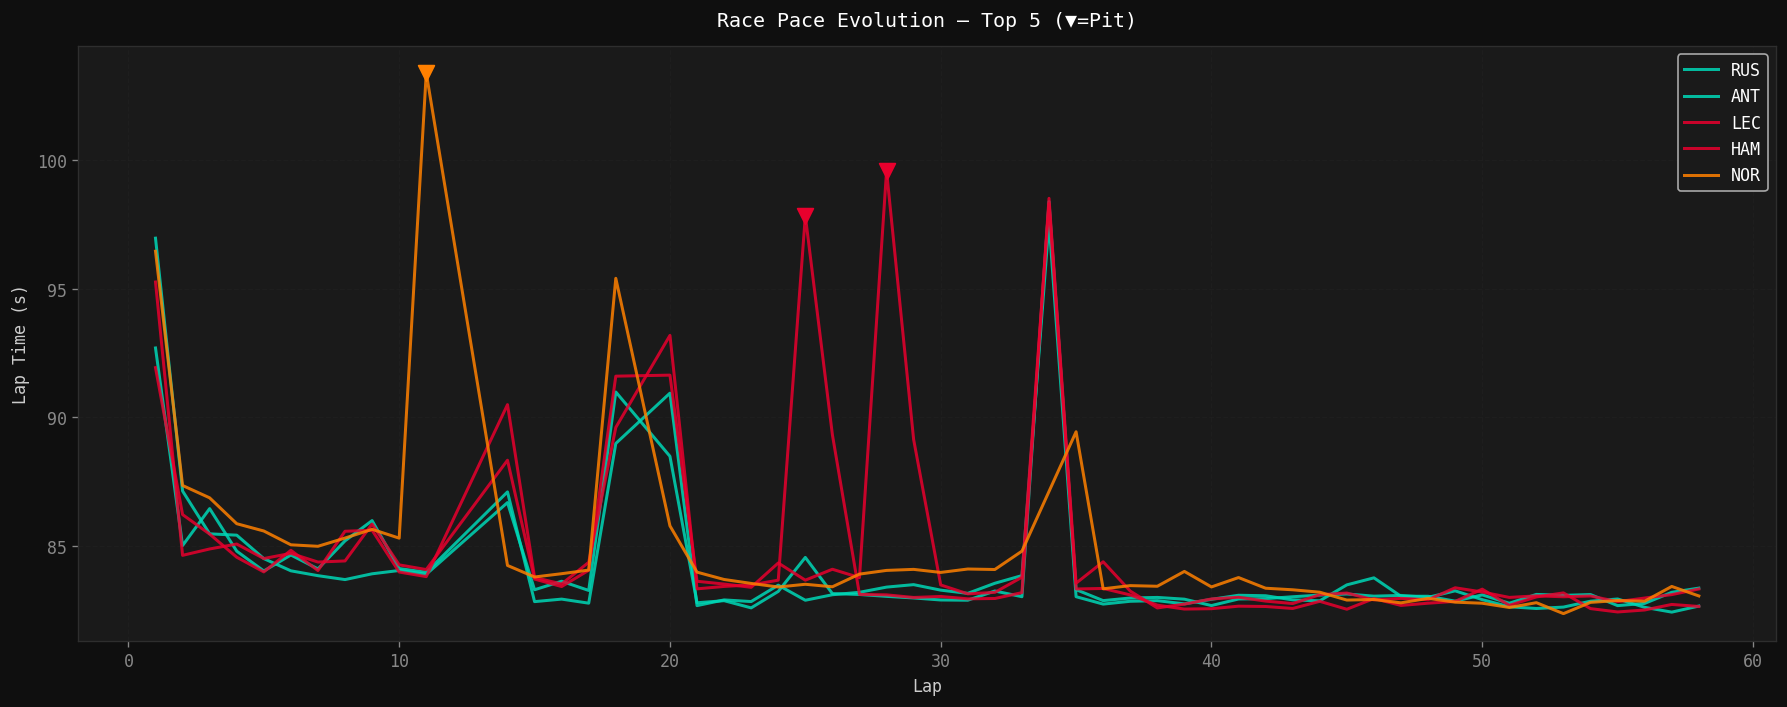

In [29]:
# ── 7.2 Race pace evolution — Top 5 ─────────────────────────
top5 = race_clean.dropna(subset=['Position']).sort_values('Position').head(5)['Driver'].tolist()

fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor('#0f0f0f')

for driver in top5:
    drv = race_laps[(race_laps['Driver']==driver) &
                    race_laps['LapTime'].notna() &
                    (race_laps['LapTime']<110)]
    c = driver_color.get(driver,'#888888')
    ax.plot(drv['LapNumber'], drv['LapTime'], color=c, linewidth=1.8, alpha=0.85, label=driver)
    pits = drv[drv['PitInTime'].notna()]
    ax.scatter(pits['LapNumber'], pits['LapTime'], color=c, marker='v', s=90, zorder=6)

ax.set_xlabel('Lap'); ax.set_ylabel('Lap Time (s)')
ax.set_title('Race Pace Evolution — Top 5 (▼=Pit)', color='white', pad=12)
ax.legend(facecolor='#1a1a1a', labelcolor='white')
ax.grid(alpha=0.25)
plt.tight_layout(); savefig('06_race_pace_top5.png'); plt.show()


## 8. 🔧 Tyre Strategy

  💾 ./figures_eda/07_tyre_strategy.png


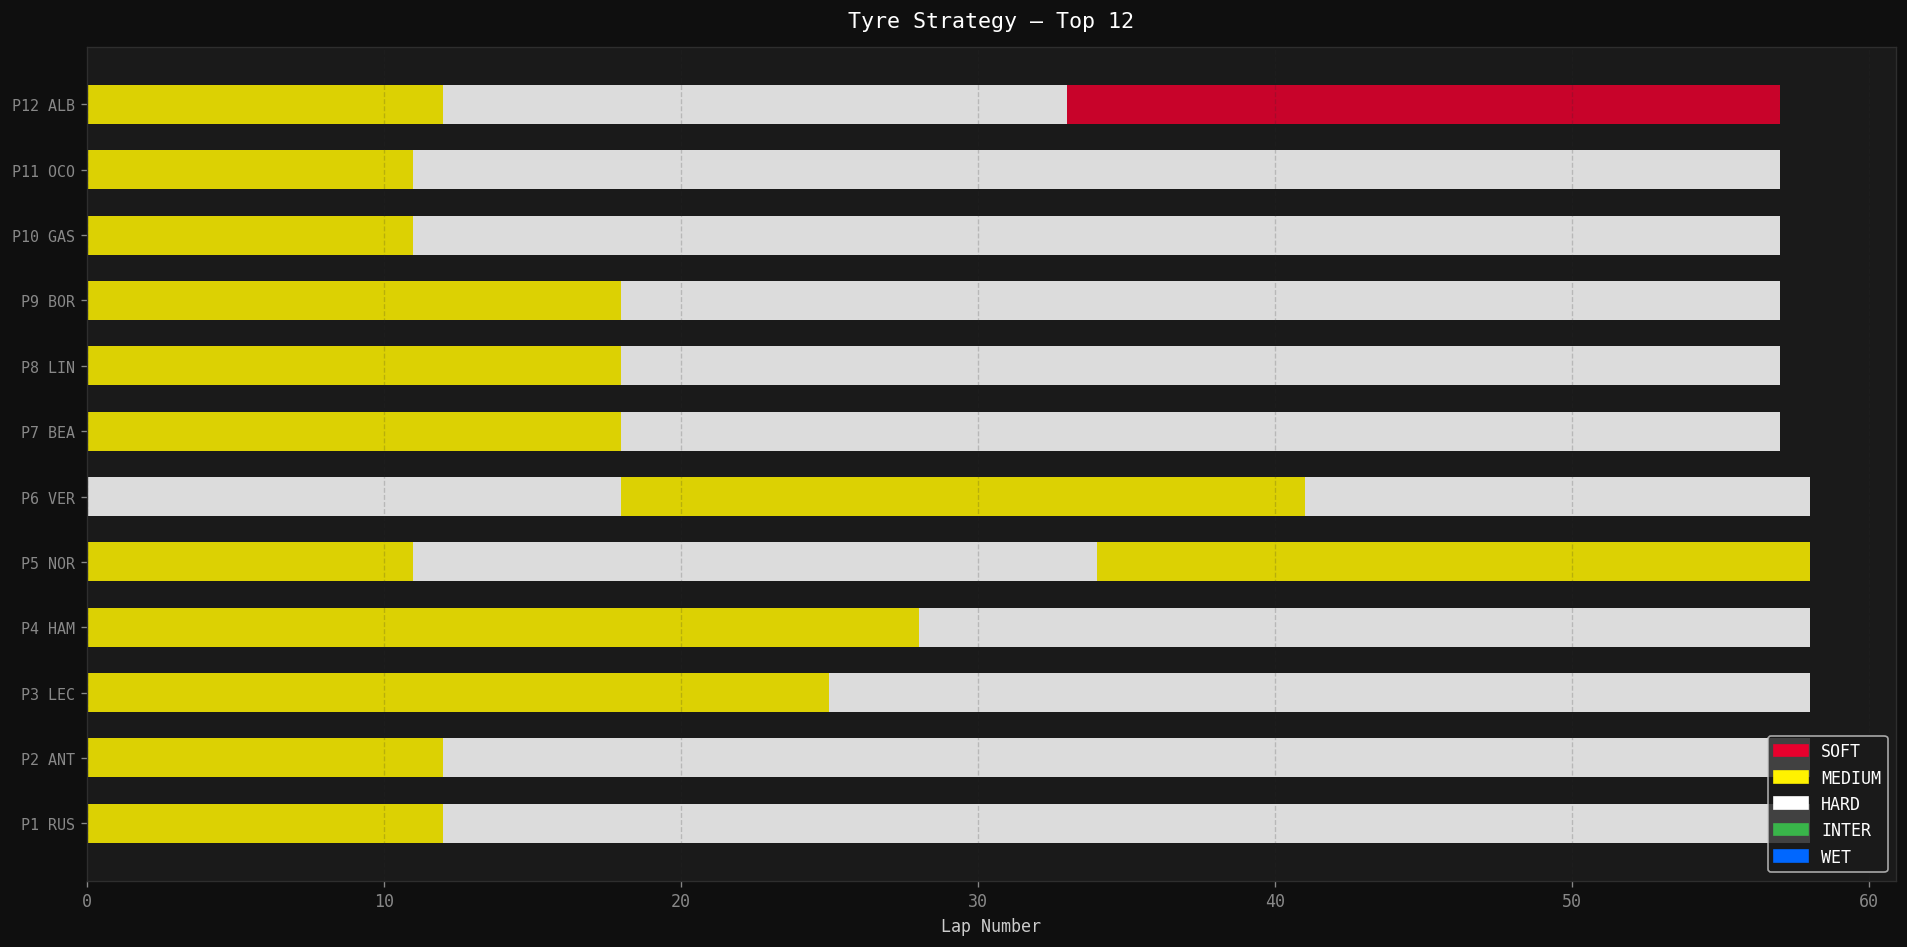

In [30]:
# ── 8.1 Strategy timeline — Top 12 ──────────────────────────
top12 = race_clean.dropna(subset=['Position']).sort_values('Position').head(12)['Driver'].tolist()

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#0f0f0f')

for i, driver in enumerate(top12):
    for _, lap in race_laps[race_laps['Driver']==driver].sort_values('LapNumber').iterrows():
        comp = str(lap['Compound']) if pd.notna(lap['Compound']) else 'UNKNOWN'
        ax.barh(i, 1, left=lap['LapNumber']-1, height=0.6,
                color=TYRE_COLORS.get(comp,'#555'), alpha=0.85)

ax.set_yticks(range(len(top12)))
ax.set_yticklabels([f'P{i+1} {d}' for i,d in enumerate(top12)], fontsize=9)
ax.set_xlabel('Lap Number')
ax.set_title('Tyre Strategy — Top 12', color='white', pad=12, fontsize=13)
ax.legend(handles=[mpatches.Patch(color=c,label=t) for t,c in TYRE_COLORS.items()],
          loc='lower right', facecolor='#1a1a1a', labelcolor='white')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout(); savefig('07_tyre_strategy.png'); plt.show()


  💾 ./figures_eda/08_tyre_degradation.png


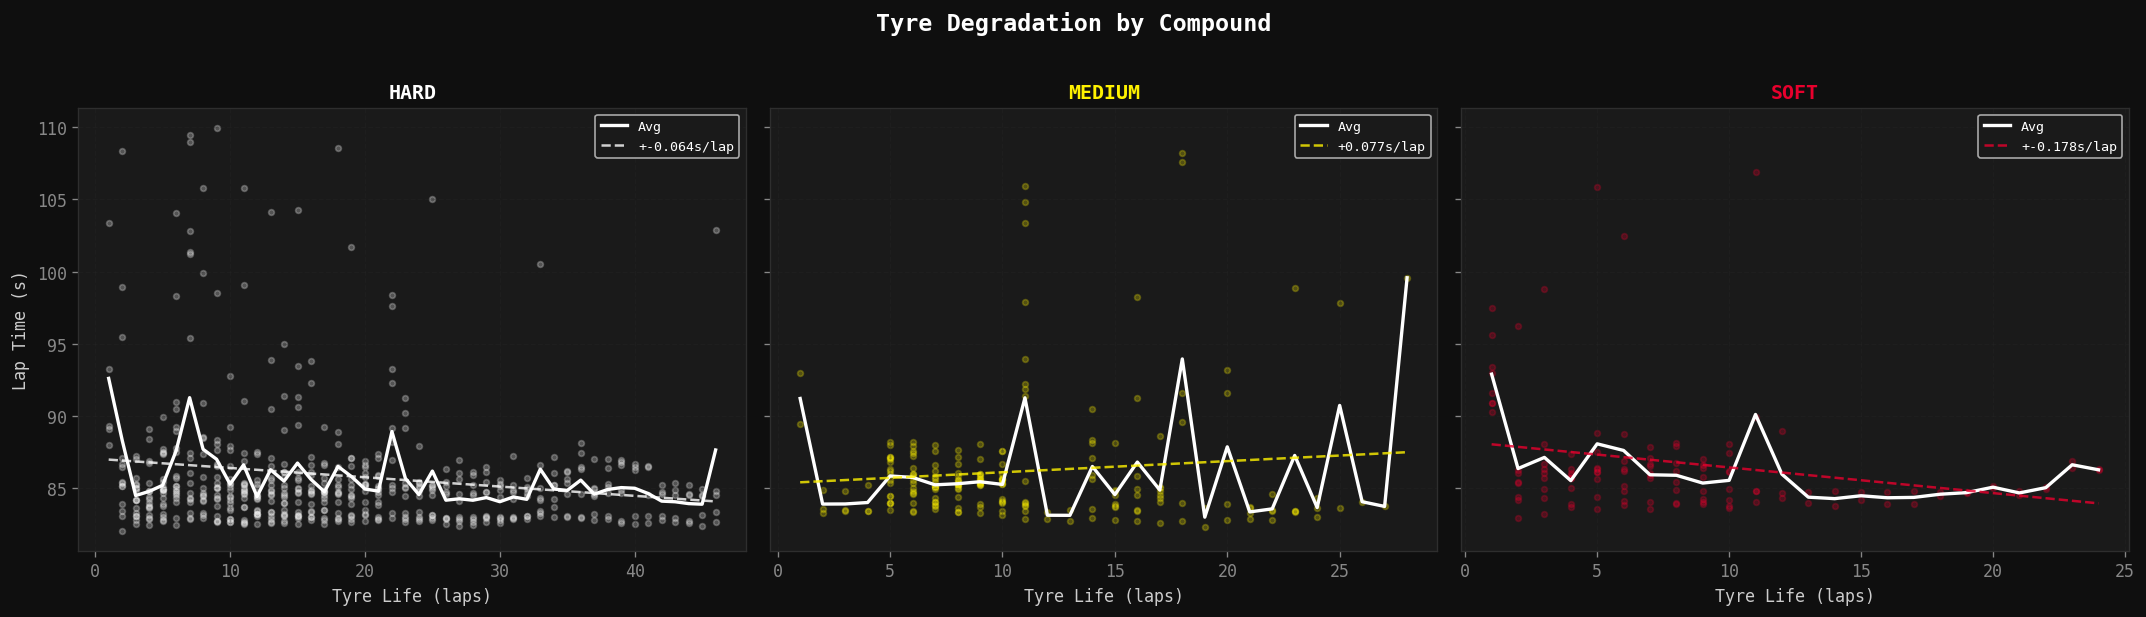

In [31]:
# ── 8.2 Tyre degradation ─────────────────────────────────────
deg = race_laps[race_laps['LapTime'].notna() & race_laps['TyreLife'].notna() &
                (race_laps['LapTime']<110) & (race_laps['LapNumber']>4)].copy()
compounds = sorted(deg['Compound'].dropna().unique())

fig, axes = plt.subplots(1, len(compounds), figsize=(6*len(compounds), 5), sharey=True)
fig.patch.set_facecolor('#0f0f0f')

for ax, comp in zip(axes, compounds):
    data = deg[deg['Compound']==comp]
    c = TYRE_COLORS.get(comp,'#888')
    ax.scatter(data['TyreLife'], data['LapTime'], color=c, alpha=0.25, s=12)
    avg = data.groupby('TyreLife')['LapTime'].mean()
    ax.plot(avg.index, avg.values, color='white', linewidth=2, label='Avg')
    if len(data)>5:
        z = np.polyfit(data['TyreLife'], data['LapTime'], 1)
        xl = np.linspace(data['TyreLife'].min(), data['TyreLife'].max(), 100)
        ax.plot(xl, np.poly1d(z)(xl), '--', color=c, linewidth=1.5,
                alpha=0.8, label=f'+{z[0]:.3f}s/lap')
    ax.set_xlabel('Tyre Life (laps)'); ax.set_title(comp, color=c, fontsize=12, fontweight='bold')
    ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8); ax.grid(alpha=0.25)

axes[0].set_ylabel('Lap Time (s)')
plt.suptitle('Tyre Degradation by Compound', color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); savefig('08_tyre_degradation.png'); plt.show()


## 9. 🌤️ Weather Analysis

  💾 ./figures_eda/09_weather.png


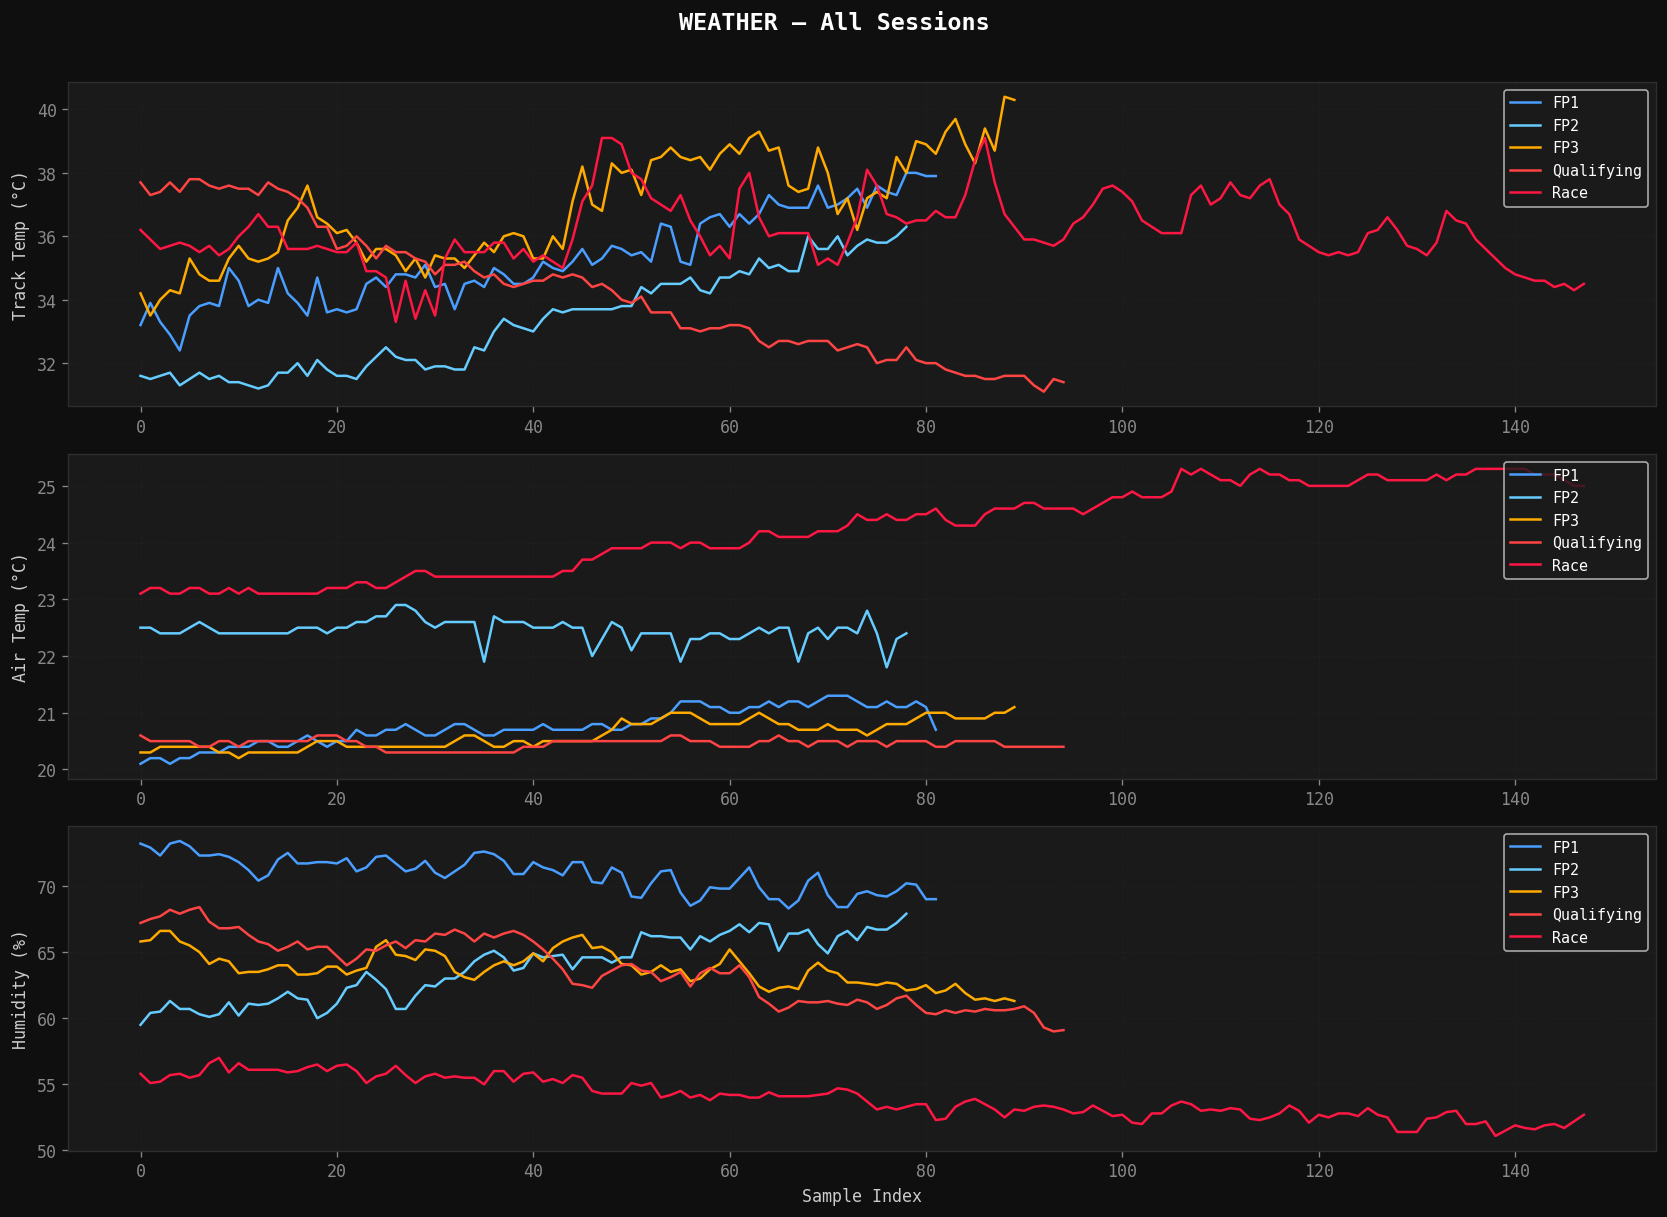

Weather summary:
   Session  AirTemp_mean  AirTemp_max  TrackTemp_mean  TrackTemp_max  Rainfall
       FP1          20.8         21.3            35.3           38.0     False
       FP2          22.5         22.9            33.3           36.3     False
       FP3          20.6         21.1            36.9           40.4     False
Qualifying          20.5         20.6            34.3           37.8     False
      Race          24.2         25.3            36.1           39.1     False


In [32]:
weather_sessions = [
    (fp1_w,'FP1','#4a9eff'),(fp2_w,'FP2','#66ccff'),
    (fp3_w,'FP3','#ffaa00'),(quali_w,'Qualifying','#ff4444'),
    (race_w,'Race','#ff1744'),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.patch.set_facecolor('#0f0f0f')

for df, label, color in weather_sessions:
    idx = range(len(df))
    axes[0].plot(idx, df['TrackTemp'], color=color, label=label, linewidth=1.5)
    axes[1].plot(idx, df['AirTemp'],   color=color, label=label, linewidth=1.5)
    axes[2].plot(idx, df['Humidity'],  color=color, label=label, linewidth=1.5)

for ax, ylabel in zip(axes, ['Track Temp (°C)','Air Temp (°C)','Humidity (%)']):
    ax.set_ylabel(ylabel); ax.grid(alpha=0.25)
    ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=9, loc='upper right')

axes[2].set_xlabel('Sample Index')
plt.suptitle('WEATHER — All Sessions', color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); savefig('09_weather.png'); plt.show()

# Summary table
print('Weather summary:')
rows = []
for df, sess, _ in weather_sessions:
    rows.append({'Session':sess,
                 'AirTemp_mean':round(df['AirTemp'].mean(),1),
                 'AirTemp_max':df['AirTemp'].max(),
                 'TrackTemp_mean':round(df['TrackTemp'].mean(),1),
                 'TrackTemp_max':df['TrackTemp'].max(),
                 'Rainfall':df['Rainfall'].any()})
print(pd.DataFrame(rows).to_string(index=False))


## 10. 🔍 Correlation & Feature Insights

  💾 ./figures_eda/10_correlation_matrix.png


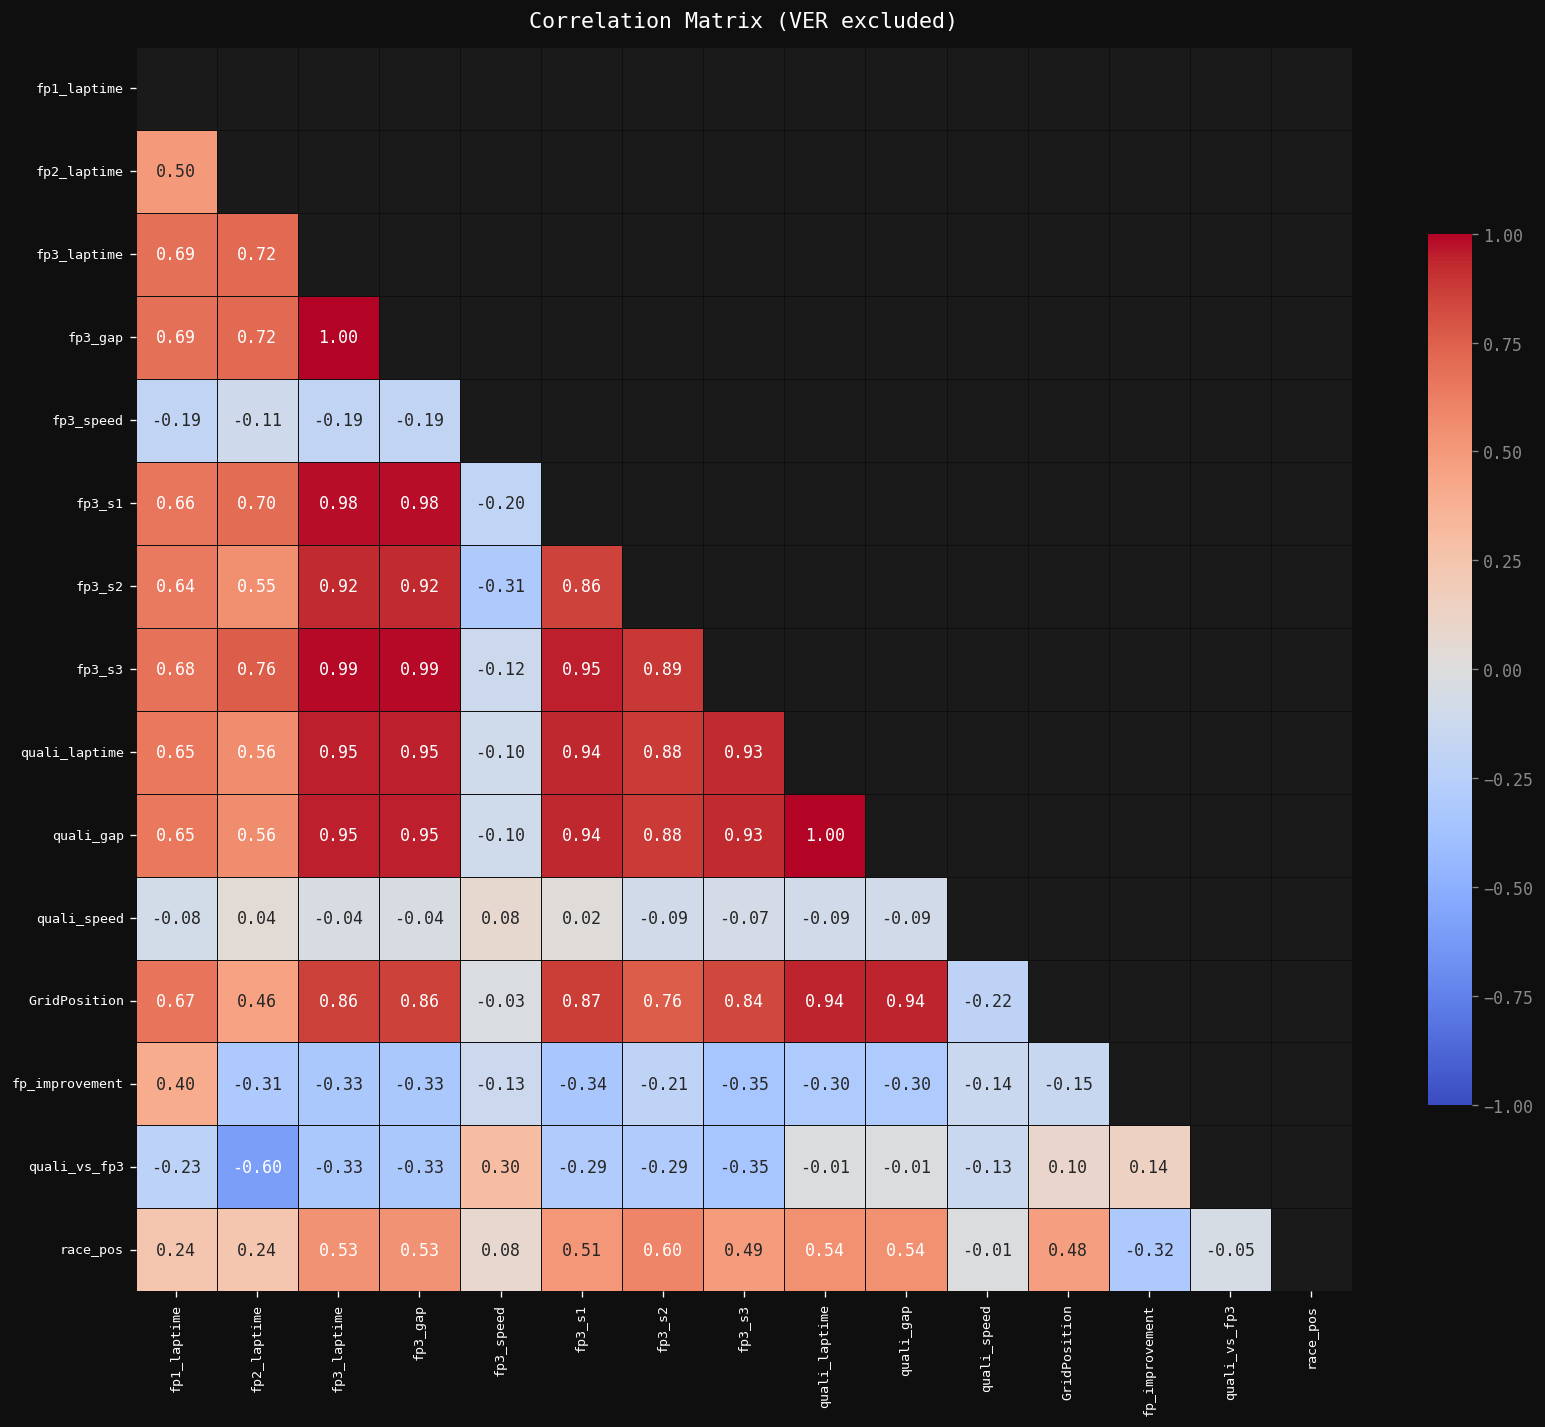


Top correlations with race_pos:
  fp3_s2                   : +0.597  ██████████████ (↑ worse)
  quali_gap                : +0.545  █████████████ (↑ worse)
  quali_laptime            : +0.545  █████████████ (↑ worse)
  fp3_laptime              : +0.532  █████████████ (↑ worse)
  fp3_gap                  : +0.532  █████████████ (↑ worse)
  fp3_s1                   : +0.512  ████████████ (↑ worse)
  fp3_s3                   : +0.486  ████████████ (↑ worse)
  GridPosition             : +0.476  ███████████ (↑ worse)
  fp_improvement           : -0.316  ███████ (↑ better)
  fp1_laptime              : +0.238  █████ (↑ worse)
  fp2_laptime              : +0.236  █████ (↑ worse)
  fp3_speed                : +0.078  █ (↑ worse)
  quali_vs_fp3             : -0.054  █ (↑ better)
  quali_speed              : -0.011   (↑ better)


In [33]:
# ── 10.1 Correlation matrix ──────────────────────────────────
feature_cols = [
    'fp1_laptime','fp2_laptime','fp3_laptime',
    'fp3_gap','fp3_speed','fp3_s1','fp3_s2','fp3_s3',
    'quali_laptime','quali_gap','quali_speed',
    'GridPosition','fp_improvement','quali_vs_fp3','race_pos'
]

corr_data = df_drivers[~df_drivers['quali_anomaly']][feature_cols].copy()
corr_data['race_pos'] = corr_data['race_pos'].astype(float)

# fillna trước khi tính corr
corr_data = corr_data.fillna(corr_data.median(numeric_only=True))
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('#0f0f0f')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax, mask=mask,
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f',
            linewidths=0.4, linecolor='#0f0f0f',
            cbar_kws={'shrink':0.7})
ax.set_title('Correlation Matrix (VER excluded)', color='white', pad=12, fontsize=13)
ax.tick_params(colors='white', labelsize=8)
plt.tight_layout(); savefig('10_correlation_matrix.png'); plt.show()

print('\nTop correlations with race_pos:')
corr_target = corr_matrix['race_pos'].drop('race_pos').dropna().sort_values(key=abs, ascending=False)
for feat, val in corr_target.items():
    bar = '█' * int(abs(val)*25)
    direction = '(↑ worse)' if val>0 else '(↑ better)'
    print(f'  {feat:25s}: {val:+.3f}  {bar} {direction}')


  💾 ./figures_eda/11_key_predictors.png


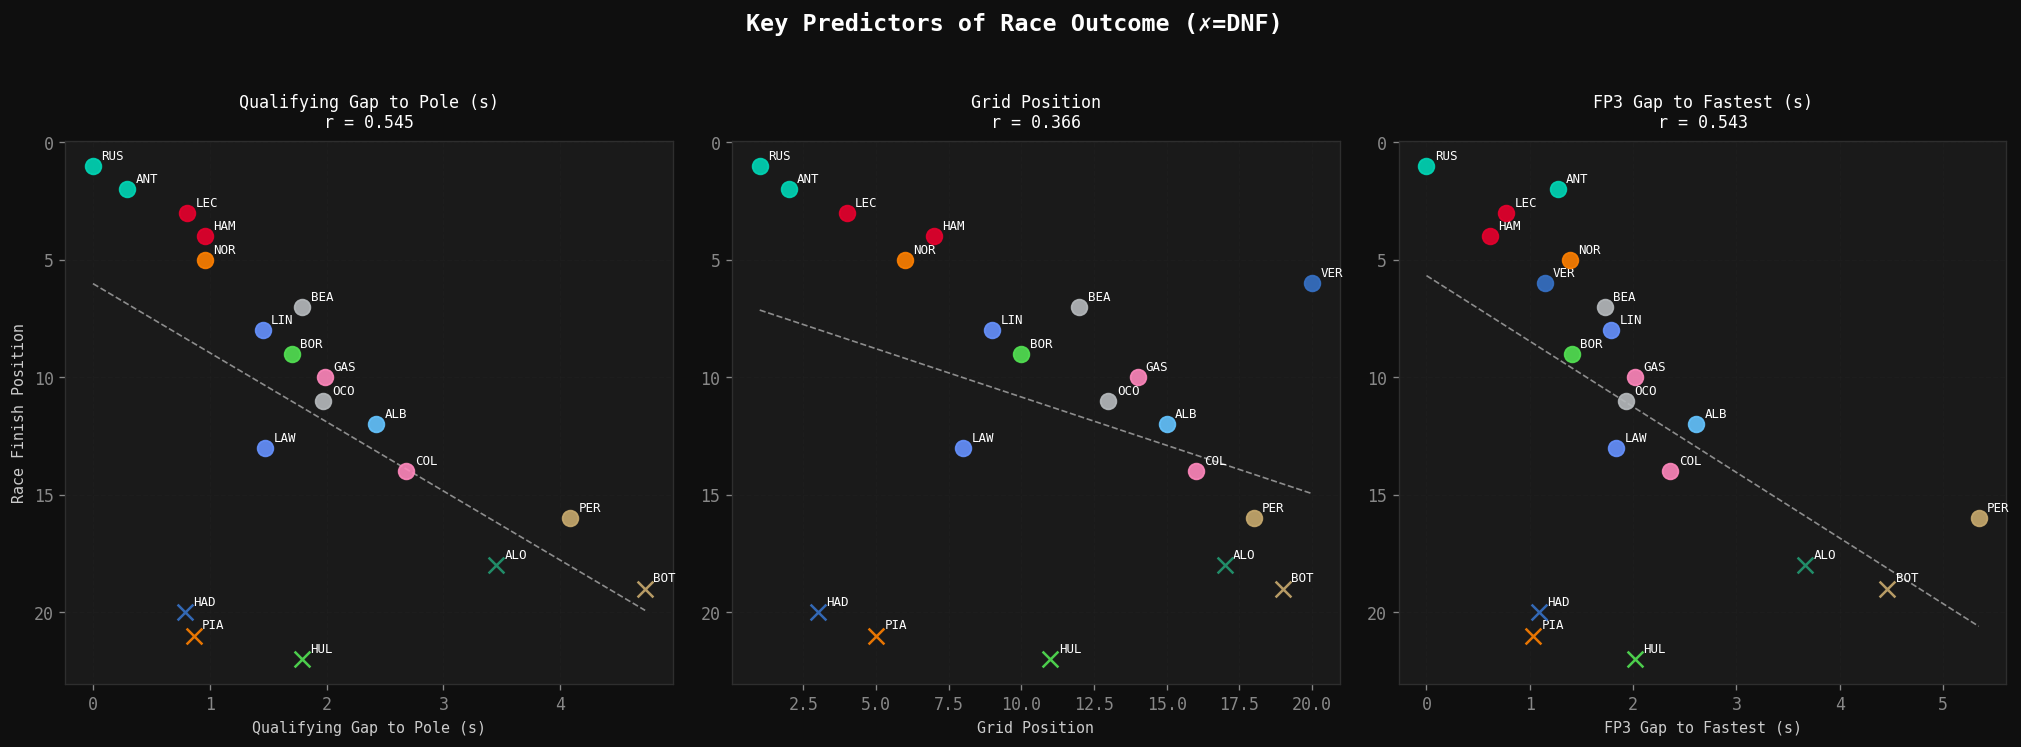

In [34]:
# ── 10.2 Key predictors scatter ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.patch.set_facecolor('#0f0f0f')

pairs = [('quali_gap','Qualifying Gap to Pole (s)'),
         ('GridPosition','Grid Position'),
         ('fp3_gap','FP3 Gap to Fastest (s)')]

plot_data = df_drivers.dropna(subset=['race_pos']).copy()
plot_data['race_pos'] = plot_data['race_pos'].astype(float)

for ax, (x_col, x_label) in zip(axes, pairs):
    valid = plot_data.dropna(subset=[x_col,'race_pos'])
    if x_col == 'quali_gap':
        valid = valid[~valid['quali_anomaly']]

    for _, row in valid.iterrows():
        c = TEAM_COLORS.get(row['Team'],'#888888')
        m = 'x' if row['dnf'] else 'o'
        ax.scatter(row[x_col], row['race_pos'], color=c, s=90, marker=m, alpha=0.9, zorder=5)
        ax.annotate(row['Driver'], (row[x_col], row['race_pos']),
                    textcoords='offset points', xytext=(5,4), fontsize=7.5, color='white')

    if len(valid)>2:
        z = np.polyfit(valid[x_col], valid['race_pos'], 1)
        xl = np.linspace(valid[x_col].min(), valid[x_col].max(), 100)
        ax.plot(xl, np.poly1d(z)(xl), '--', color='white', linewidth=1, alpha=0.5)
        r_val = valid[[x_col,'race_pos']].corr().iloc[0,1]
        ax.set_title(f'{x_label}\nr = {r_val:.3f}', color='white', fontsize=10, pad=8)
    else:
        ax.set_title(x_label, color='white', fontsize=10, pad=8)

    ax.set_xlabel(x_label, fontsize=9)
    if ax==axes[0]: ax.set_ylabel('Race Finish Position', fontsize=9)
    ax.grid(alpha=0.2); ax.invert_yaxis()

plt.suptitle('Key Predictors of Race Outcome (✗=DNF)',
             color='white', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout(); savefig('11_key_predictors.png'); plt.show()


## 11. 💾 Save Processed Data

In [35]:
import os
os.makedirs('processed', exist_ok=True)

# df_drivers: drop list column
df_drivers_save = df_drivers.drop(columns=['pit_laps'], errors='ignore')
df_drivers_save.to_csv('processed/df_drivers.csv', index=False)

df_laps.to_csv('processed/df_laps.csv', index=False)

print('✅ Saved:')
print(f'   processed/df_drivers.csv — {df_drivers_save.shape}')
print(f'   processed/df_laps.csv    — {df_laps.shape}')
print()
print(f'📁 Figures saved to ./{FIG_DIR}/:')
import glob
for f in sorted(glob.glob(f'{FIG_DIR}/*.png')):
    print(f'   {f}')
print()
print('🎯 Ready for Notebook 02 — Feature Engineering & ML!')


✅ Saved:
   processed/df_drivers.csv — (20, 53)
   processed/df_laps.csv    — (2259, 19)

📁 Figures saved to ././figures_eda/:
   ./figures_eda\01_fp_pace_evolution.png
   ./figures_eda\02_fp3_sector_heatmap.png
   ./figures_eda\03_qualifying_gap.png
   ./figures_eda\04_qualifying_segments.png
   ./figures_eda\05_race_grid_vs_finish.png
   ./figures_eda\06_race_pace_top5.png
   ./figures_eda\07_tyre_strategy.png
   ./figures_eda\08_tyre_degradation.png
   ./figures_eda\09_weather.png
   ./figures_eda\10_correlation_matrix.png
   ./figures_eda\11_key_predictors.png

🎯 Ready for Notebook 02 — Feature Engineering & ML!
